## Question 3 - *Maintenance rate vs machine CPU class*

**Metric / definition.**
- We interpret maintenance as machine unavailability periods.
- For each machine, a downtime interval starts at `REMOVE` and ends at the next `ADD`.
- Maintenance rate per machine = `downtime_fraction = total_downtime / trace_duration`.
- Machines are grouped into CPU bins of width 0.1: `[0.0,0.1), ..., [0.9,1.0]`.

**Method (Spark RDD).**
1. Parse `machine_events` into `(machine_id, (ts, event_type, cpu))`.
2. Compute trace duration from min/max timestamps (≈ 29 days).
3. For each machine: sort events by time and sum downtime over `REMOVE → ADD` pairs.
4. Join downtime with machine CPU capacity (taken from earliest ADD event when available).
5. Aggregate downtime statistics by CPU bin.

In [1]:
import sys
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

PATH_MACHINE_EVENTS = "./data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "./data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "./data/task_events/*.csv.gz"
PATH_TASK_USAGE = "./data/task_usage/*.csv.gz"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/14 23:04:52 WARN Utils: Your hostname, im2ag-mandelbrot, resolves to a loopback address: 127.0.1.1; using 152.77.81.20 instead (on interface ens18)
26/01/14 23:04:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/14 23:04:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

In [3]:
# ----------------------------
# Parsing machine events
# ----------------------------
def parse_machine_event(line):
    parts = line.split(",")
    # Defensive: some lines may be malformed
    if len(parts) < 6:
        return None
    
    ts = to_long(parts[0])
    mid = to_long(parts[1])
    et = to_int(parts[2])
    cpu = to_float(parts[4])
    mem = to_float(parts[5])
    
    if ts is None or mid is None or et is None:
        return None
    
    return (mid, (ts, et, cpu, mem))

In [4]:
# ----------------------------
# Load RDD
# ----------------------------
raw = sc.textFile(PATH_MACHINE_EVENTS)
machine_events = raw.map(parse_machine_event).filter(lambda x: x is not None).cache()

In [5]:
# Exploring the dataset: machine_events
print("\n" + "="*80)
print("Exploring the dataset: machine_events")
print(f"Number of records: {raw.count()}")
print("First record:")
print(raw.first())
print(f"Type of elements: {type(raw.first())}")


Exploring the dataset: machine_events


Number of records: 37780
First record:
0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
Type of elements: <class 'str'>


In [6]:
# ----------------------------
# Compute trace boundaries
# ----------------------------
timestamps = machine_events.map(lambda x: x[1][0])
trace_start = timestamps.min()
trace_end = timestamps.max()
trace_duration = trace_end - trace_start

print("Trace start (us):", trace_start)
print("Trace end   (us):", trace_end)
print("Trace duration (us):", trace_duration)

Trace start (us): 0
Trace end   (us): 2506135493517
Trace duration (us): 2506135493517


In [7]:
# ----------------------------
# CPU capacity per machine
# We take CPU from the earliest ADD event (event_type==0).
# ----------------------------
adds_cpu = (
    machine_events
    .filter(lambda x: x[1][1] == 0 and x[1][2] is not None)           
    .map(lambda x: (x[0], (x[1][0], x[1][2])))                       
    .reduceByKey(lambda a, b: a if a[0] < b[0] else b)
    .mapValues(lambda t: t[1])
)

fallback_cpu = (
    machine_events
    .filter(lambda x: x[1][2] is not None)
    .map(lambda x: (x[0], (x[1][0], x[1][2])))
    .reduceByKey(lambda a, b: a if a[0] < b[0] else b)
    .mapValues(lambda t: t[1])
)

cpu_by_machine = adds_cpu.union(fallback_cpu).reduceByKey(lambda a, b: a)  # prefer ADD when present
cpu_by_machine = cpu_by_machine.cache()

In [8]:
# ----------------------------
# Downtime per machine from REMOVE -> next ADD
# Count maintenance cycles
# ----------------------------
def compute_downtime_and_cycles(events_iter):
    events = sorted(events_iter, key=lambda e: e[0])
    offline_start = None
    downtime = 0
    cycles = 0
    
    for (ts, et, cpu, mem) in events:
        if et == 1:  # REMOVE
            if offline_start is None:
                offline_start = ts
        elif et == 0:  # ADD
            if offline_start is not None:
                downtime += (ts - offline_start)
                cycles += 1
                offline_start = None
    
    # If machine is removed but not added back within trace, ignore open interval
    return downtime, cycles

downtime_and_cycles = (
    machine_events
    .mapValues(lambda x: (x[0], x[1], x[2], x[3]))
    .groupByKey()
    .mapValues(compute_downtime_and_cycles)          # (mid, (downtime_us, cycles))
    .cache()
)

# Convert to downtime fraction (maintenance rate)
maintenance_rate = downtime_and_cycles.mapValues(
    lambda dc: (dc[0] / trace_duration if trace_duration > 0 else 0.0, dc[1])
)
# (mid, (downtime_fraction, cycles))

In [9]:
# ----------------------------
# Join with CPU and bin by CPU class
# ----------------------------
def cpu_bin_label(cpu, step=0.1):
    if cpu is None:
        return None
    # handle cpu == 1.0: force into last bin
    if cpu >= 1.0:
        lo = 1.0 - step
        hi = 1.0
    else:
        idx = int(cpu / step)
        lo = idx * step
        hi = lo + step
    return f"[{lo:.1f},{hi:.1f})"

joined = maintenance_rate.join(cpu_by_machine)
# (mid, ((downtime_fraction, cycles), cpu))

by_bin = (
    joined
    .map(lambda x: (cpu_bin_label(x[1][1], 0.1), (x[1][0][0], x[1][0][1], 1)))  # (bin, (downtime_frac, cycles, 1))
    .filter(lambda x: x[0] is not None)
)

# Aggregate per bin: sum downtime_frac, sum cycles, count
bin_stats = (
    by_bin
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2]))
    .mapValues(lambda s: {
        "avg_downtime_frac": s[0] / s[2],
        "avg_cycles": s[1] / s[2],
        "count": s[2]
    })
    .collect()
)

# Sort bins in numeric order
def bin_key(lbl):
    lo = float(lbl.split(",")[0].replace("[",""))
    return lo

bin_stats = sorted(bin_stats, key=lambda x: bin_key(x[0]))

# Display result table
for b, stats in bin_stats:
    print(b, stats)

[0.2,0.3) {'avg_downtime_frac': 0.010790875814181955, 'avg_cycles': 0.8015873015873016, 'count': 126}
[0.5,0.6) {'avg_downtime_frac': 0.00499021270703738, 'avg_cycles': 0.6982588558195385, 'count': 11659}
[0.9,1.0) {'avg_downtime_frac': 0.003258560550834963, 'avg_cycles': 0.7744360902255639, 'count': 798}


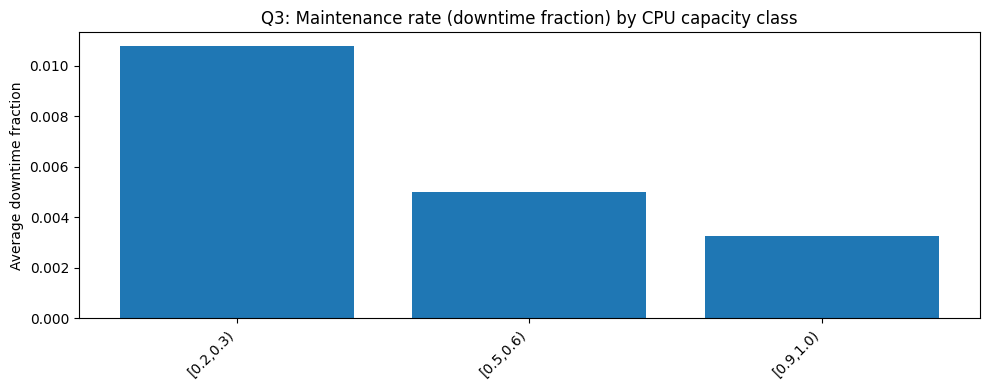

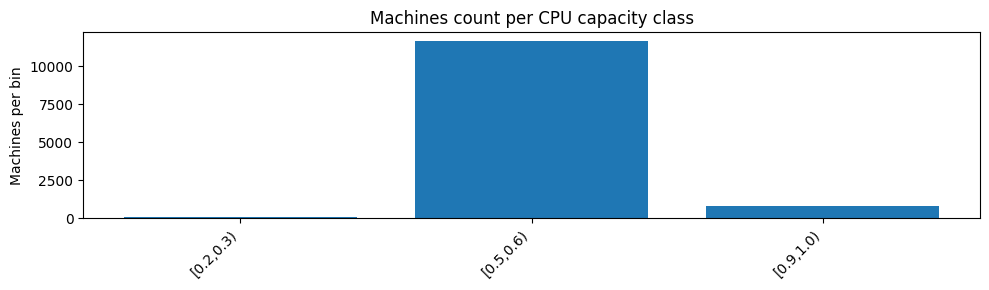

In [10]:
# Plot: average downtime fraction per CPU bin
bins = [b for b, _ in bin_stats]
avg_down = [stats["avg_downtime_frac"] for _, stats in bin_stats]
counts = [stats["count"] for _, stats in bin_stats]

plt.figure(figsize=(10, 4))
plt.bar(bins, avg_down)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average downtime fraction")
plt.title("Q3: Maintenance rate (downtime fraction) by CPU capacity class")
plt.tight_layout()
# plt.savefig("../figures/q3_downtime_by_cpu_bin.png", dpi=300, bbox_inches="tight")
plt.show()

# Show counts to ensure bins aren't too sparse
plt.figure(figsize=(10, 3))
plt.bar(bins, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Machines per bin")
plt.title("Machines count per CPU capacity class")
plt.tight_layout()
# plt.savefig("../figures/q3_machines_count_by_cpu_bin.png", dpi=300, bbox_inches="tight")
plt.show()

**Results.**

| CPU bin | #machines | avg downtime fraction | avg downtime (%) | avg maintenance cycles |
|---|---:|---:|---:|---:|
| [0.2,0.3) | 126 | 0.01079 | **1.079%** | 0.802 |
| [0.5,0.6) | 11,659 | 0.00499 | 0.499% | 0.698 |
| [0.9,1.0) | 798 | 0.00326 | 0.326% | 0.774 |

**Interpretation.**
A CPU class that stands out is **[0.2, 0.3)**, with an average downtime fraction of **~1.08%**, which is about **2.16×**  higher than the large [0.5, 0.6) class (**~0.50%**) and about **3.3×** higher than the [0.9, 1.0) class (~0.33%).

However, this result must be interpreted carefully because the [0.2, 0.3) class contains only **126 machines**, while [0.5, 0.6) contains **11,659 machines** (dominant population). This means the high maintenance rate for the low-CPU class could be influenced by:
- a small sample size (higher variance / sensitivity to outliers),
- a specific subgroup of machines (e.g., older / less reliable hardware pool),
- operational policies (low-capacity machines being used differently or more frequently taken out for maintenance).